### Importing modules and dataset

In [210]:
import kagglehub
import os

import random

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [211]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [212]:
path = kagglehub.dataset_download("shreyapmaher/fruits-dataset-images")
images_path = os.path.join(path, "images")

In [213]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop((IMG_HEIGHT, IMG_WIDTH)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=images_path, transform=transform)

print(f"Classes: {dataset.classes}")
print(f"Total images: {len(dataset)}")

Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Total images: 359


In [214]:
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size])

batch_size = 32

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)

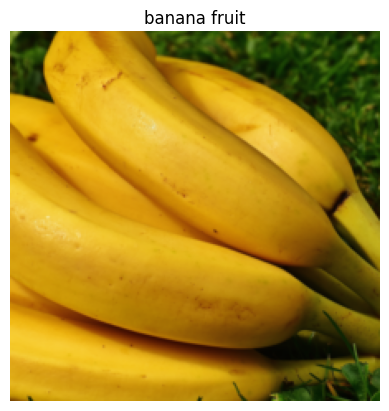

In [215]:
random_idx = random.randint(0, len(train_set) - 1)
image, label = train_set[random_idx]
plt.imshow(image.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

### Data augmentation

In [216]:
augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(15, fill=(128, 128, 128)),
    transforms.RandomResizedCrop((IMG_WIDTH, IMG_HEIGHT), scale=(.8, 1), ratio=(1, 1)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=.2, contrast=.3)
])

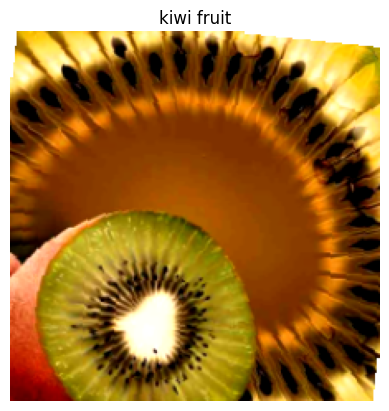

In [217]:
random_idx = random.randint(0, len(train_set) - 1)
image, label = train_set[random_idx]
image_transformed = augmentation_transforms(image).cpu()
plt.imshow(image_transformed.permute(1, 2, 0))
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

### Data preprocessing

In [218]:
class ScalingLayer(nn.Module):
    def __init__(self, mean: torch.Tensor, std: torch.Tensor):
        super().__init__()
        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(std).view(1, 3, 1, 1))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return (X - self.mean) / (self.std + 1e-8)

In [219]:
class PreprocessingLayer(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.scaler = ScalingLayer(mean, std)
    
    def forward(self, X):
        return self.scaler(X)

### Convolutional Neural Network Model and training loop

In [ ]:
class FruitCNN(nn.Module):
    def __init__(self, mean, std, num_classes):
        super().__init__()
        self.preprocessing = PreprocessingLayer(mean, std)
        self.cnn = nn.Sequential(
            
            # Aqui colocar capas convolucionales

            nn.Flatten(),

            # Aqui colocar red neuronal densa

            # Ejemplo
            nn.Linear(75 * 3 * 3, 512),
            nn.Dropout(0.3),
            nn.ReLU(),

            nn.Linear(512, num_classes)
        )

    def forward(self, X):
        X = self.preprocessing(X)
        X = self.cnn(X)
        return X

### Model creation

In [225]:
mean = torch.zeros(3)
std  = torch.zeros(3)

simple_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

for images, labels in simple_loader:
    for c in range(3):
        mean[c] += images[:, c, :, :].mean()
        std[c]  += images[:, c, :, :].std()

mean /= len(simple_loader)
std  /= len(simple_loader)

print(f"Mean: {mean.tolist()}")
print(f"Std:  {std.tolist()}")

Mean: [0.6926469802856445, 0.5376335978507996, 0.3582891523838043]
Std:  [0.263290673494339, 0.2990576922893524, 0.33447349071502686]


In [226]:
fruit_model = FruitCNN(mean, std, num_classes=len(dataset.classes))

fruit_model = fruit_model.to(device)

C:\Users\carlo\AppData\Local\Temp\ipykernel_24732\178968750.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
C:\Users\carlo\AppData\Local\Temp\ipykernel_24732\178968750.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('std',  torch.tensor(std).view(1, 3, 1, 1))
